In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Gender":["Male","Female","Female","Male","Female","Male","Female","Male"],

    "Education":["UG","PG","PhD","UG","PG","UG","PhD","PG"],

    "Experience":[1,5,7,2,8,3,10,6],

    "Salary":[25000,60000,90000,30000,85000,35000,100000,70000],

    "Department":["HR","IT","Sales","IT","HR","Sales","IT","HR"]
}

df = pd.DataFrame(data)

df

,Gender,Education,Experience,Salary,Department
0,Male,UG,1,25000,HR
1,Female,PG,5,60000,IT
2,Female,PhD,7,90000,Sales
3,Male,UG,2,30000,IT
4,Female,PG,8,85000,HR
5,Male,UG,3,35000,Sales
6,Female,PhD,10,100000,IT
7,Male,PG,6,70000,HR


In [3]:
le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])

df

,Gender,Education,Experience,Salary,Department,Gender_Label
0,Male,UG,1,25000,HR,1
1,Female,PG,5,60000,IT,0
2,Female,PhD,7,90000,Sales,0
3,Male,UG,2,30000,IT,1
4,Female,PG,8,85000,HR,0
5,Male,UG,3,35000,Sales,1
6,Female,PhD,10,100000,IT,0
7,Male,PG,6,70000,HR,1


In [5]:
le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])

df

,Gender,Education,Experience,Salary,Department,Gender_Label
0,Male,UG,1,25000,HR,1
1,Female,PG,5,60000,IT,0
2,Female,PhD,7,90000,Sales,0
3,Male,UG,2,30000,IT,1
4,Female,PG,8,85000,HR,0
5,Male,UG,3,35000,Sales,1
6,Female,PhD,10,100000,IT,0
7,Male,PG,6,70000,HR,1


In [7]:
onehot = pd.get_dummies(df,
                        columns=["Department"])

onehot.head()

,Gender,Education,Experience,Salary,Gender_Label,Department_HR,Department_IT,Department_Sales
0,Male,UG,1,25000,1,True,False,False
1,Female,PG,5,60000,0,False,True,False
2,Female,PhD,7,90000,0,False,False,True
3,Male,UG,2,30000,1,False,True,False
4,Female,PG,8,85000,0,True,False,False


In [8]:
onehot = pd.get_dummies(df,
                        columns=["Department"])

onehot.head()

,Gender,Education,Experience,Salary,Gender_Label,Department_HR,Department_IT,Department_Sales
0,Male,UG,1,25000,1,True,False,False
1,Female,PG,5,60000,0,False,True,False
2,Female,PhD,7,90000,0,False,False,True
3,Male,UG,2,30000,1,False,True,False
4,Female,PG,8,85000,0,True,False,False


In [9]:
ordinal = OrdinalEncoder(
    categories=[["UG","PG","PhD"]]
)

df["Education_Ordinal"] = ordinal.fit_transform(
    df[["Education"]]
)

df

,Gender,Education,Experience,Salary,Department,Gender_Label,Education_Ordinal
0,Male,UG,1,25000,HR,1,0.0
1,Female,PG,5,60000,IT,0,1.0
2,Female,PhD,7,90000,Sales,0,2.0
3,Male,UG,2,30000,IT,1,0.0
4,Female,PG,8,85000,HR,0,1.0
5,Male,UG,3,35000,Sales,1,0.0
6,Female,PhD,10,100000,IT,0,2.0
7,Male,PG,6,70000,HR,1,1.0


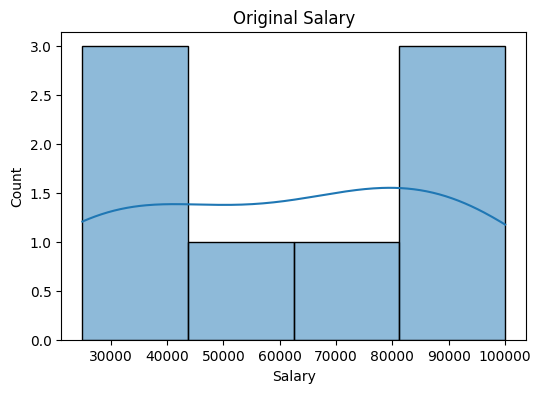

In [10]:
plt.figure(figsize=(6,4))
sns.histplot(df["Salary"], kde=True)
plt.title("Original Salary")
plt.show()

In [12]:
standard = StandardScaler()

df["Standard"] = standard.fit_transform(df[["Salary"]])

df.head()

,Gender,Education,Experience,Salary,Department,Gender_Label,Education_Ordinal,Standard
0,Male,UG,1,25000,HR,1,0.0,-1.352485
1,Female,PG,5,60000,IT,0,1.0,-0.068770
2,Female,PhD,7,90000,Sales,0,2.0,1.031557
3,Male,UG,2,30000,IT,1,0.0,-1.169098
4,Female,PG,8,85000,HR,0,1.0,0.848169


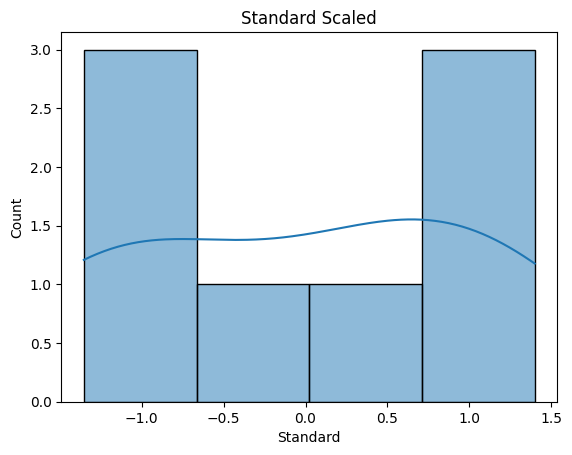

In [13]:
sns.histplot(df["Standard"], kde=True)
plt.title("Standard Scaled")
plt.show()

In [14]:
minmax = MinMaxScaler()

df["MinMax"] = minmax.fit_transform(df[["Salary"]])

df.head()

,Gender,Education,Experience,Salary,Department,Gender_Label,Education_Ordinal,Standard,MinMax
0,Male,UG,1,25000,HR,1,0.0,-1.352485,0.000000
1,Female,PG,5,60000,IT,0,1.0,-0.068770,0.466667
2,Female,PhD,7,90000,Sales,0,2.0,1.031557,0.866667
3,Male,UG,2,30000,IT,1,0.0,-1.169098,0.066667
4,Female,PG,8,85000,HR,0,1.0,0.848169,0.800000


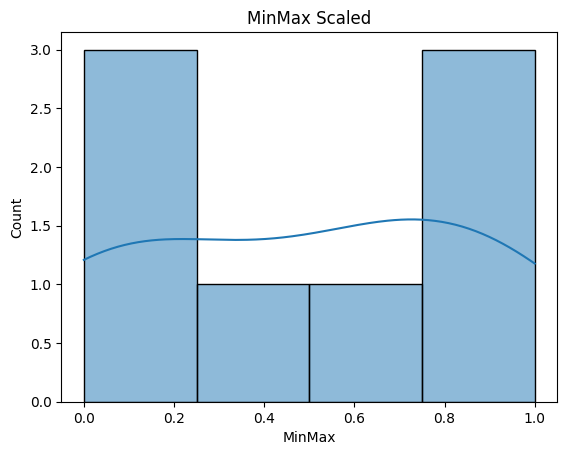

In [15]:
sns.histplot(df["MinMax"], kde=True)
plt.title("MinMax Scaled")
plt.show()

In [16]:
robust = RobustScaler()

df["Robust"] = robust.fit_transform(df[["Salary"]])

df.head()

,Gender,Education,Experience,Salary,Department,Gender_Label,Education_Ordinal,Standard,MinMax,Robust
0,Male,UG,1,25000,HR,1,0.0,-1.352485,0.000000,-0.761905
1,Female,PG,5,60000,IT,0,1.0,-0.068770,0.466667,-0.095238
2,Female,PhD,7,90000,Sales,0,2.0,1.031557,0.866667,0.476190
3,Male,UG,2,30000,IT,1,0.0,-1.169098,0.066667,-0.666667
4,Female,PG,8,85000,HR,0,1.0,0.848169,0.800000,0.380952


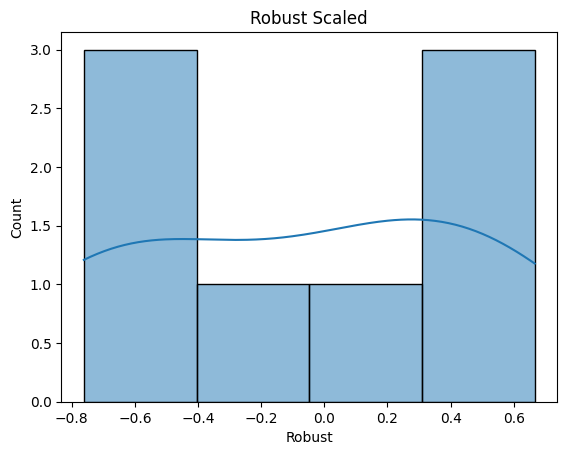

In [17]:
sns.histplot(df["Robust"], kde=True)
plt.title("Robust Scaled")
plt.show()

In [ ]:
StandardScaler

• Mean becomes 0
• Standard deviation becomes 1

MinMaxScaler

• Values between 0 and 1

RobustScaler

• Less affected by outliers

In [20]:
X = df[[
    "Experience",
    "Salary",
    "Gender_Label",
    "Education_Ordinal"
]]

y = [0,1,1,0,1,0,1,1]

In [21]:
selector = SelectKBest(score_func=f_classif,
                       k="all")

selector.fit(X,y)

scores = pd.DataFrame({
    "Feature":X.columns,
    "Score":selector.scores_
})

scores.sort_values(
    by="Score",
    ascending=False
)

,Feature,Score
1,Salary,27.346963
3,Education_Ordinal,18.375000
0,Experience,18.107143
2,Gender_Label,9.000000


In [22]:
df["Age"]=[22,25,29,23,31,24,35,30]

In [23]:
X = df[[
    "Experience",
    "Salary",
    "Gender_Label",
    "Education_Ordinal",
    "Age"
]]

In [25]:
selector = SelectKBest(f_classif,k=5)

selector.fit(X,y)

scores = pd.DataFrame({
    "Feature":X.columns,
    "Score":selector.scores_
})

scores.sort_values(
    by="Score",
    ascending=False
)

,Feature,Score
1,Salary,27.346963
3,Education_Ordinal,18.375000
0,Experience,18.107143
4,Age,10.208333
2,Gender_Label,9.000000
